# Figures 3-5: Dense Shelf Water budgets

We follow Dense Shelf Water (DSW), defined as shelf water denser than the minimum density of SWMT, and plot its mass budget (Figure 3), the spatial decomposition of the change in its SWMT (Figure 4), and the contribution of each surface flux to that change (Figure 5).
The shelf budget is produced by `01_prepare_dsw_wmt_budget`; the minimum DSW densities and period-mean SWMT maps by `03_prepare_dsw_densities_and_periods`.

In [1]:
import sys

import cartopy.crs as ccrs
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from matplotlib.colors import BoundaryNorm

sys.path.insert(0, "../src")
from paths import outputdir, plotsdir
from wmt import get_SWMT, decompose_SWMT_spatial, select_from_location
from plotting import to_tg, expt_colors, set_style, plot_antarctic

set_style(dpi=150)


reference_period = (1900, 2000)  # historical averaging window
future_period = (2090, 2100)  # end-of-century averaging window


def add_bar_numbers(bars, ax, text_height_factor=2):
    """Write each bar's height (truncated to 2 decimals) just past its end, in the bar's color."""
    for bar in bars:
        height = bar.get_height()
        if np.abs(height) < 1e-2:
            height = 0.0
        ax.text(bar.get_x() + bar.get_width() / 2, height + np.sign(height) * text_height_factor,
                np.trunc(height * 100) / 100, horizontalalignment="center",
                color=bar.get_facecolor(), weight="bold")

In [2]:
ds = xr.open_dataset(outputdir("Southern_Ocean_DSW_1000m_WMT_Budget.zarr"))
ds_max_swmt = xr.open_dataset(outputdir("Southern_Ocean_DSW_1000m_max_SWMT.zarr"))
ds_periods = xr.open_dataset(outputdir("DSW_SWMT_periods.zarr"))

## DSW budget

In [3]:
ds["surface_boundary_fluxes"] = ds["boundary_fluxes"] - ds["bottom_flux_heat"]
ds_yearly = ds.fillna(0.0).groupby("time.year").mean("time")

# time-evolving DSW definition, and a fixed one from the piControl mean
dsw_density = ds_max_swmt["max_surface_boundary_flux_density"]
dsw_density_fixed = float(dsw_density.sel(exp="control").mean("year"))

dsw_budget = to_tg * select_from_location(ds_yearly, dsw_density).sel(year=slice(1850, None))
dsw_budget_fixed = to_tg * ds_yearly.sel(sigma2_l_target=dsw_density_fixed, method="nearest").sel(year=slice(1850, None))
dsw_swmt = get_SWMT(dsw_budget)
dsw_swmt_fixed = get_SWMT(dsw_budget_fixed)

periods = [reference_period, future_period]
period_labels = [f"{start}–{end}" for start, end in periods]
period_colors = ["grey", expt_colors["forced"]]

/user/anthony.meza/CM4XAbyssalSWMT/notebooks/../src/wmt.py:127: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  results.append(xr.concat(exp_data, dim="year"))
/user/anthony.meza/CM4XAbyssalSWMT/notebooks/../src/wmt.py:127: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  results.append(xr.concat(exp_data, dim="year")

## Figure 3

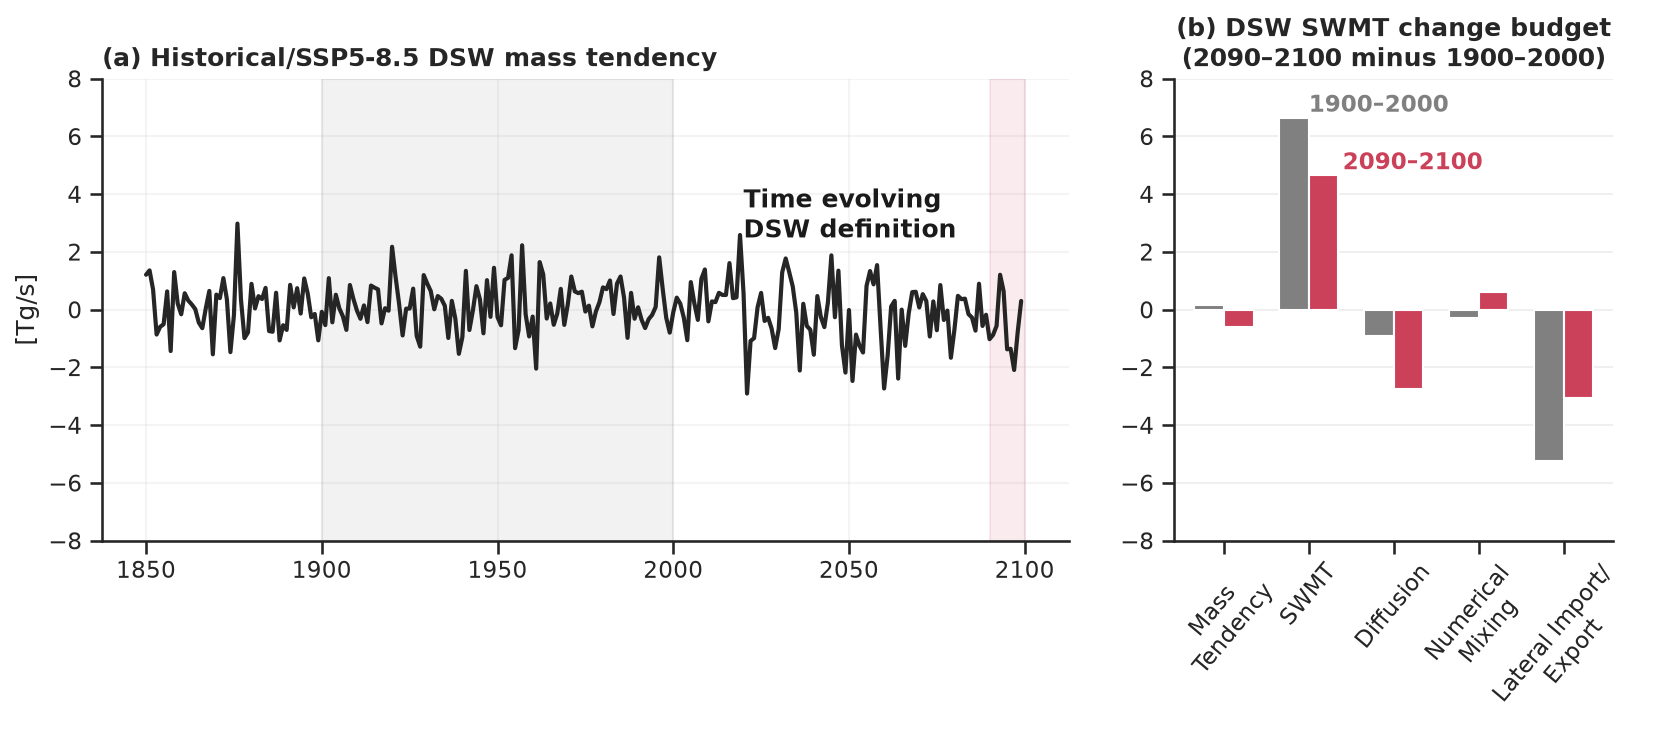

In [4]:
budget_terms = ["mass_tendency", "surface_boundary_fluxes", "diffusion",
                "spurious_numerical_mixing", "convergent_mass_transport"]
budget_labels = ["Mass\nTendency", "SWMT", "Diffusion", "Numerical\nMixing", "Lateral Import/\nExport"]

fig = plt.figure(figsize=(13, 4.0))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2.2, 1.0], wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax1.grid(alpha=0.4, axis="y")
ax1.grid(alpha=0.2)
ax1.plot(dsw_budget.year, dsw_budget["mass_tendency"].sel(exp="forced"), linewidth=2.0, alpha=0.95, c="k")
ax1.set_ylabel("[Tg/s]")
ax1.set_title("(a) Historical/SSP5-8.5 DSW mass tendency", fontweight="bold", loc="left")
for (start, end), color in zip(periods, period_colors):
    ax1.axvspan(start, end, color=color, alpha=0.1)
ax1.text(2020, 2.5, "Time evolving\nDSW definition", color="k", ha="left", fontsize=12, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax2.set_title("(b) DSW SWMT change budget\n(2090–2100 minus 1900–2000)", fontweight="bold")
x = np.arange(len(budget_labels))
width = 0.35
for i, ((start, end), label, color) in enumerate(zip(periods, period_labels, period_colors)):
    period_mean = dsw_budget.sel(exp="forced", year=slice(start, end)).mean("year")
    values = [period_mean[term].values.item() for term in budget_terms]
    ax2.bar(x + (i - 0.5) * width, values, width=width, color=color)
    ax2.text(x[1] + i * 0.4, values[1] + 0.2, label, color=color, ha="left", fontsize=11, fontweight="bold")
ax2.set_xticks(x, budget_labels, rotation=50)
ax2.grid(alpha=0.3)
ax2.xaxis.grid(False)

for a in [ax1, ax2]:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.set_ylim(-8, 8)

fig.savefig(plotsdir("fig03_dsw_mass_budget.png"), dpi=350, bbox_inches="tight")

## Figure 4

In [5]:
swmt_ref, swmt_future = [ds_periods.sel(period=f"{start}-{end}").drop_vars("period") for start, end in periods]
swmt_decomp = to_tg * decompose_SWMT_spatial(swmt_ref["SWMT"], swmt_future["SWMT"], dims=("xh", "yh"))

per_area = to_tg / ds_periods.areacello  # kg/s per cell -> Tg/s/m^2
swmt_ref_map = swmt_ref["SWMT"] * per_area
swmt_future_map = swmt_future["SWMT"] * per_area
swmt_diff_map = swmt_future_map.fillna(0.0) - swmt_ref_map.fillna(0.0)
swmt_diff_map = swmt_diff_map.where(np.abs(swmt_diff_map) > 0.0)

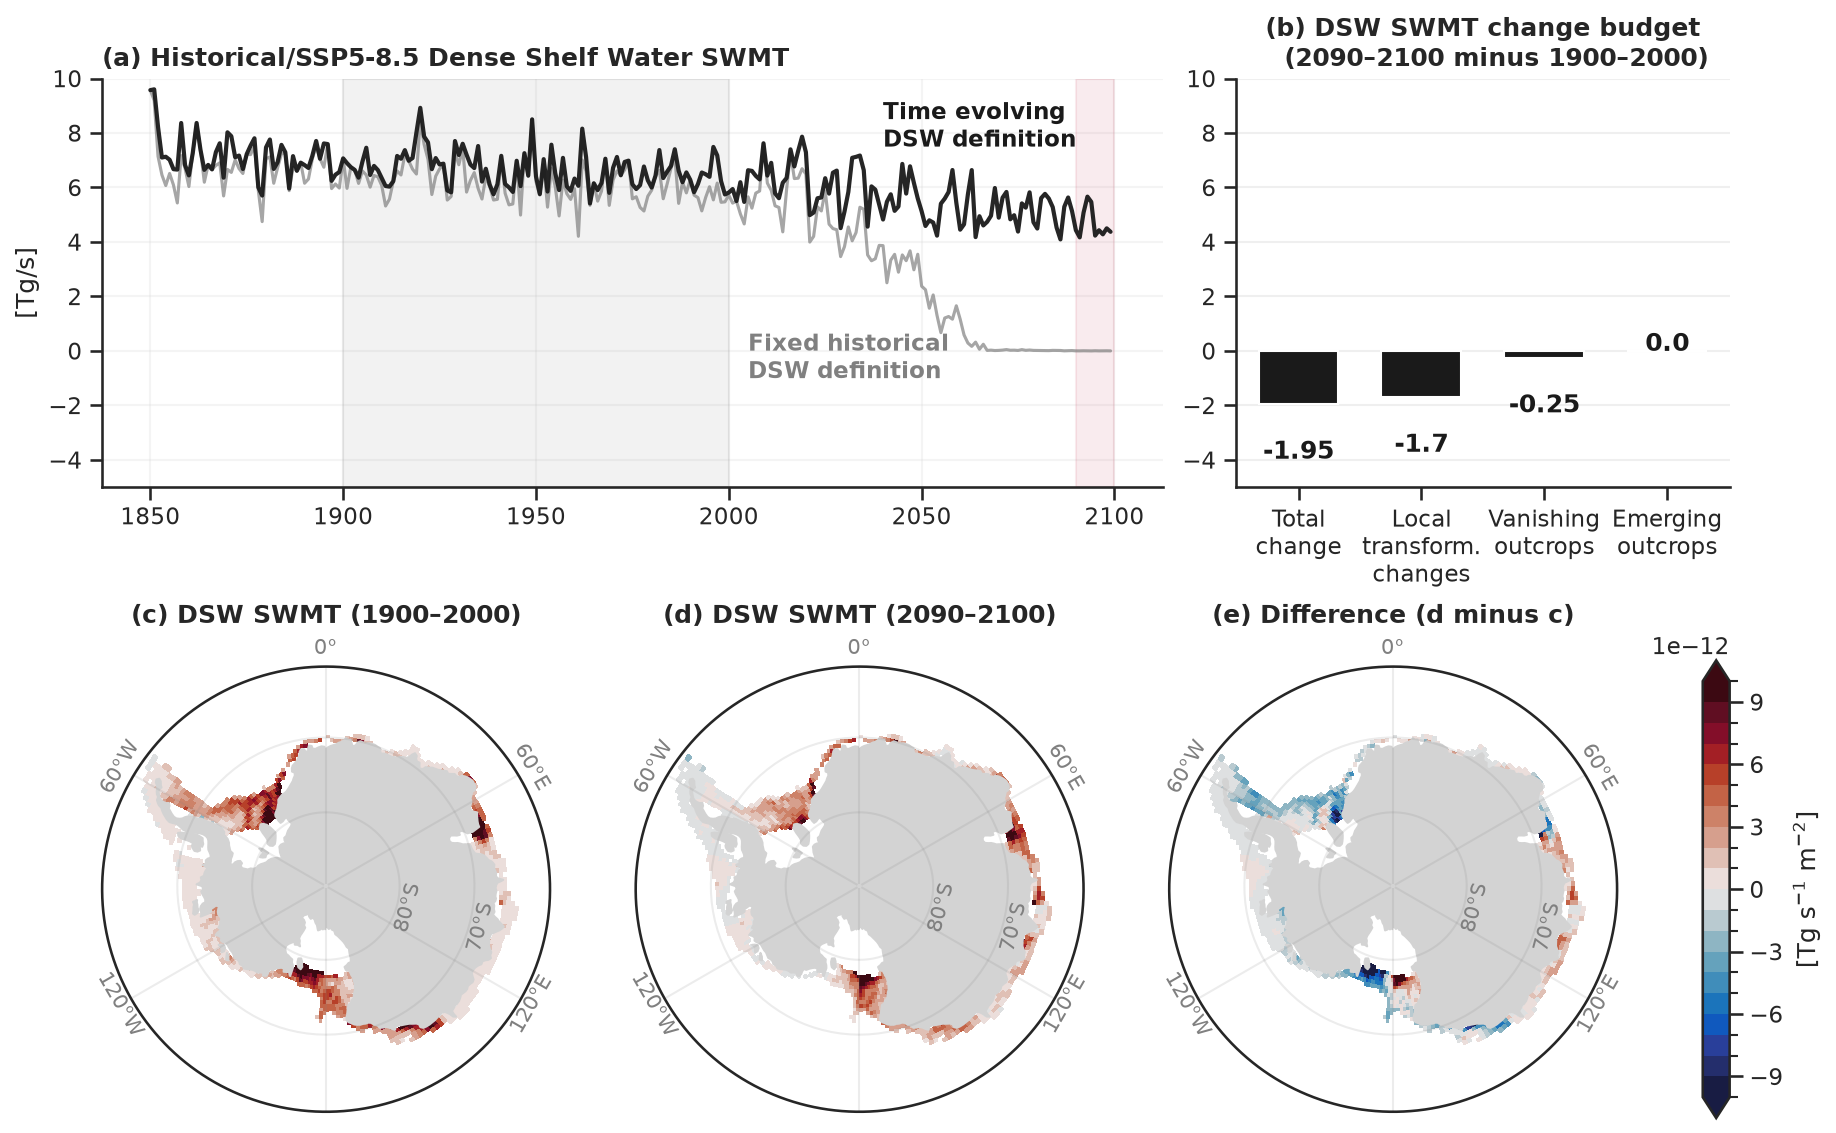

In [6]:
fig = plt.figure(figsize=(14, 9))
outer = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1.0, 1.12], hspace=0.4)

gs_top = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=outer[0], wspace=0.35)
ax1 = fig.add_subplot(gs_top[0, :4])
ax1.grid(alpha=0.4, axis="y")
ax1.grid(alpha=0.2)
ax1.plot(dsw_swmt_fixed.year, dsw_swmt_fixed["SWMT"].sel(exp="forced"), linewidth=1.5, alpha=0.7, c="grey")
ax1.plot(dsw_swmt.year, dsw_swmt["SWMT"].sel(exp="forced"), linewidth=2.0, alpha=0.95, c="k")
ax1.set_ylabel("[Tg/s]")
ax1.set_title("(a) Historical/SSP5-8.5 Dense Shelf Water SWMT", fontweight="bold", loc="left")
for (start, end), color in zip(periods, period_colors):
    ax1.axvspan(start, end, color=color, alpha=0.1)
ax1.text(2005, -1.0, "Fixed historical\nDSW definition", color="grey", ha="left", fontsize=11, fontweight="bold")
ax1.text(2040, 7.5, "Time evolving\nDSW definition", color="k", ha="left", fontsize=11, fontweight="bold")

ax2 = fig.add_subplot(gs_top[0, 4:], sharey=ax1)
ax2.set_title("(b) DSW SWMT change budget\n   (2090–2100 minus 1900–2000)", fontweight="bold")
change_terms = {
    "Total\nchange": swmt_decomp["true_total"],
    "Local\ntransform.\nchanges": swmt_decomp["integrand_change"],
    "Vanishing\noutcrops": swmt_decomp["domain_shift_loss"],
    "Emerging\noutcrops": swmt_decomp["domain_shift_gain"],
}
bars = ax2.bar(list(change_terms), [v.values for v in change_terms.values()], color="k", width=0.65)
add_bar_numbers(bars, ax2)
ax2.grid(alpha=0.3)
ax2.xaxis.grid(False)

for a in [ax1, ax2]:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.set_ylim(-5, 10)

gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[1], width_ratios=[1.0, 1.0, 1.0, 0.06], wspace=0.25)
map_axes = [fig.add_subplot(gs_bottom[0, i], projection=ccrs.SouthPolarStereo()) for i in range(3)]
cax = fig.add_subplot(gs_bottom[0, 3])

boundaries = 1e-12 * np.arange(-10, 10 + 0.1, 1)
boundaries[np.abs(boundaries) < 1e-16] = 0
norm = BoundaryNorm(boundaries, cmo.balance.N)
titles = ["(c) DSW SWMT (1900–2000)", "(d) DSW SWMT (2090–2100)", "(e) Difference (d minus c)"]
for a, field, title in zip(map_axes, [swmt_ref_map, swmt_future_map, swmt_diff_map], titles):
    cm = plot_antarctic(field, a, cmap=cmo.balance, norm=norm, mask_threshold=1e-50,
                        gridline_lons=np.arange(-180, 180, 60), gridline_lats=np.arange(-90, -60, 10))
    a.set_title(title, fontweight="bold", y=1.07)

cbar = fig.colorbar(cm, cax=cax, orientation="vertical", extend="both")
cbar.set_label(r"[Tg s$^{-1}$ m$^{-2}$]")

fig.savefig(plotsdir("fig04_swmt_spatial_budget.png"), dpi=350, bbox_inches="tight")

## Figure 5

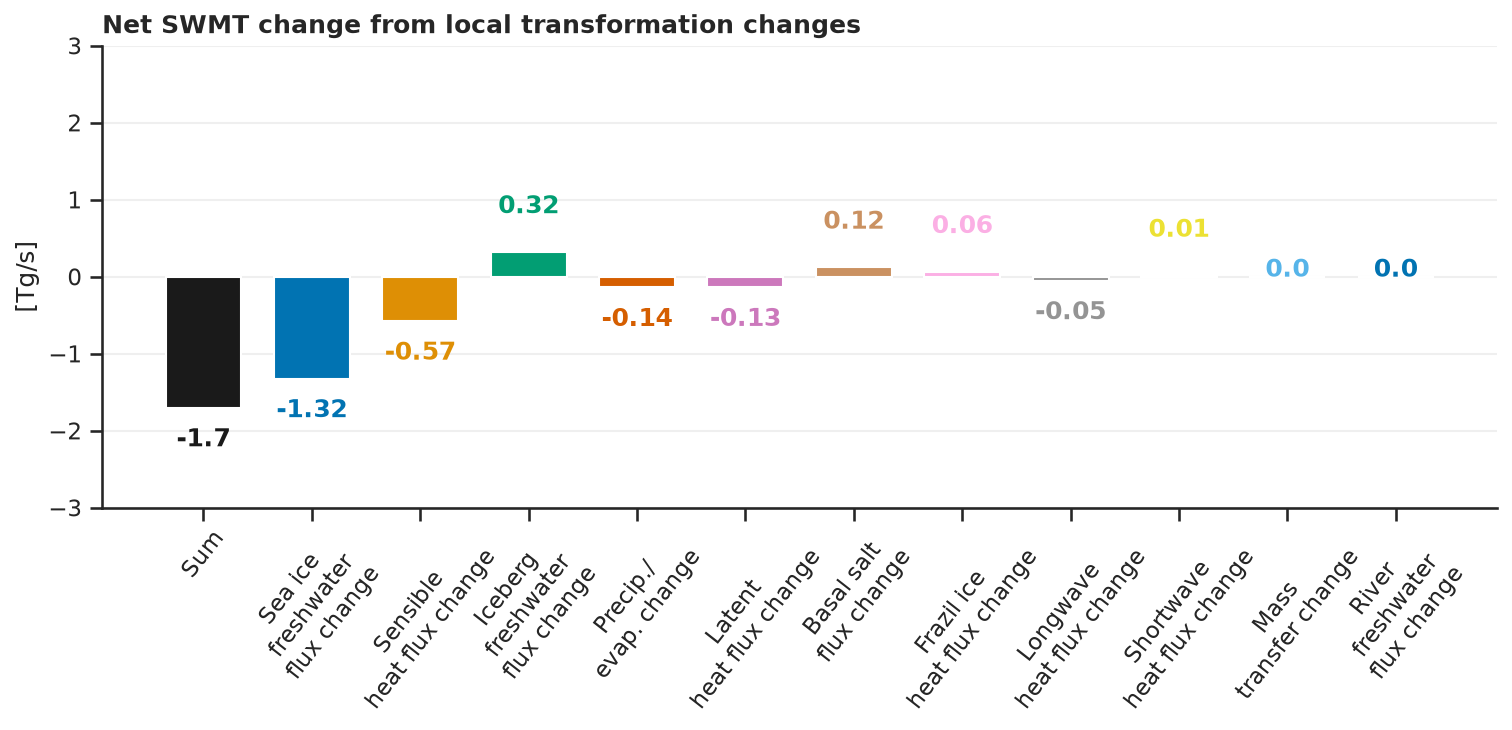

In [7]:
swmt_term_labels = {
    "SWMT_heat_latent": "Latent\nheat flux",
    "SWMT_heat_frazil": "Frazil ice\nheat flux",
    "SWMT_heat_longwave": "Longwave\nheat flux",
    "SWMT_heat_shortwave": "Shortwave\nheat flux",
    "SWMT_heat_mass_transfer": "Mass\ntransfer",
    "SWMT_heat_sensible": "Sensible\nheat flux",
    "SWMT_salt_rivers": "River\nfreshwater\nflux",
    "SWMT_salt_icebergs": "Iceberg\nfreshwater\nflux",
    "SWMT_salt_basal_salt": "Basal salt\nflux",
    "SWMT_salt_sea_ice": "Sea ice\nfreshwater\nflux",
    "SWMT_salt_precip_minus_evaporation": "Precip./\nevap.",
}
# individual surface flux terms, excluding totals, approximations and residuals
exclude_vars = {"SWMT", "SWMT_heat", "SWMT_salt", "SWMT_heat_approx", "SWMT_salt_approx",
                "SWMT_heat_residual", "SWMT_salt_residual", "SWMT_residual", "boundary_fluxes_heat"}
swmt_terms = sorted(set(dsw_swmt.data_vars) - exclude_vars)

labels = ["Sum"] + [swmt_term_labels[term] + " change" for term in swmt_terms]
changes = [swmt_decomp["integrand_change"].values] + [
    to_tg * decompose_SWMT_spatial(swmt_ref[term], swmt_future[term], dims=("xh", "yh"))["integrand_change"].values
    for term in swmt_terms
]
order = np.argsort(-np.abs(changes), kind="stable")  # largest magnitude first
labels = np.array(labels)[order]
changes = np.array(changes)[order]
colors = ["k"] + sns.color_palette("colorblind", len(changes) - 1)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(labels, changes, align="center", color=colors, width=0.7)
ax.tick_params(axis="x", labelrotation=52, labelright=False)
ax.set_ylim(-3.0, 3.0)
ax.set_ylabel("[Tg/s]")
ax.grid(alpha=0.3)
ax.xaxis.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Net SWMT change from local transformation changes", fontweight="bold", loc="left")
add_bar_numbers(bars, ax, text_height_factor=0.5)

fig.savefig(plotsdir("fig05_dsw_swmt_flux_budget.png"), dpi=350, bbox_inches="tight")